
🔍 Silhouette Score: 0.1294

✅ SVM Accuracy (balanced): 99.81%

📊 Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       514
           1       0.99      1.00      1.00       513
           2       1.00      1.00      1.00       514
           3       1.00      1.00      1.00       513

    accuracy                           1.00      2054
   macro avg       1.00      1.00      1.00      2054
weighted avg       1.00      1.00      1.00      2054

📉 Confusion Matrix:
 [[511   3   0   0]
 [  1 512   0   0]
 [  0   0 514   0]
 [  0   0   0 513]]

✅ Saved: langmarker_svm_smote_preds.csv


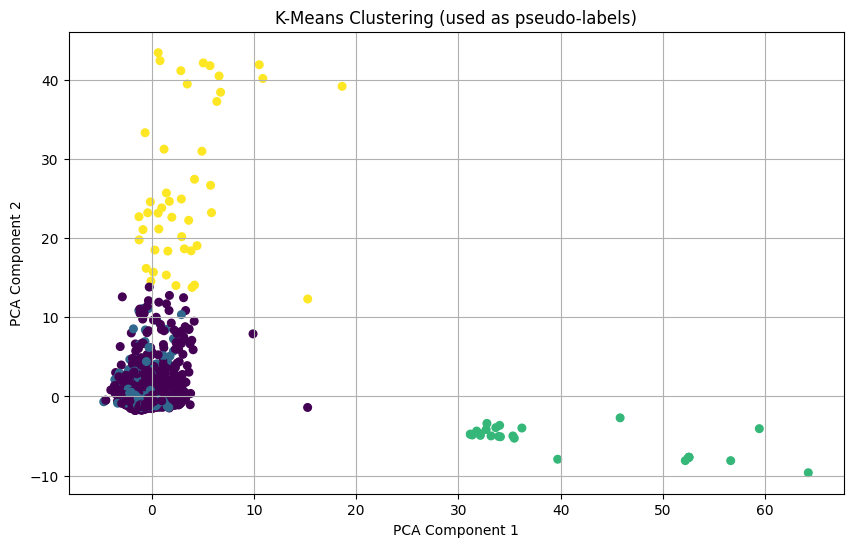

In [ ]:
# 📦 Import Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, silhouette_score
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# 📥 Load Data
df = pd.read_csv("/content/language marker.csv")

# 🔢 Numeric features only
features = df.select_dtypes(include=[np.number]).fillna(0)

# ⚖️ Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# 🎯 KMeans for Pseudo-Labels
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
pseudo_labels = kmeans.fit_predict(X_scaled)
df['Cluster'] = pseudo_labels

# 📊 Silhouette Score
sil_score = silhouette_score(X_scaled, pseudo_labels)
print(f"\n🔍 Silhouette Score: {round(sil_score, 4)}")

# 🧪 SMOTE on pseudo-labels
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, df['Cluster'])

# 🧠 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

# 🚀 Train SVM
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

# 📈 Predict & Evaluate
y_pred = svm_model.predict(X_test)
print(f"\n✅ SVM Accuracy (balanced): {round(accuracy_score(y_test, y_pred) * 100, 2)}%")
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
print("📉 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# 💾 Save for Fusion
balanced_pred_df = pd.DataFrame({
    'ID': df.index,
    'langmarker_pred': svm_model.predict(X_scaled)  # full prediction
})
balanced_pred_df.to_csv("langmarker_svm_smote_preds.csv", index=False)
print("\n✅ Saved: langmarker_svm_smote_preds.csv")

# 🎨 PCA Plot (Optional)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
plt.figure(figsize=(10, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=pseudo_labels, cmap='viridis', s=30)
plt.title("K-Means Clustering (used as pseudo-labels)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()


✅ Loaded ADNI language dataset: (3873, 86)

🔍 Silhouette Score (ADNI Language): 0.1294

✅ SVM Accuracy (balanced): 99.81%

📊 Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       514
           1       0.99      1.00      1.00       513
           2       1.00      1.00      1.00       514
           3       1.00      1.00      1.00       513

    accuracy                           1.00      2054
   macro avg       1.00      1.00      1.00      2054
weighted avg       1.00      1.00      1.00      2054

📉 Confusion Matrix:
 [[511   3   0   0]
 [  1 512   0   0]
 [  0   0 514   0]
 [  0   0   0 513]]

✅ Saved: adni_langmarker_svm_smote_preds.csv
💾 Saved: adni_language_results.pkl (for ADNI–CCNA cross-cohort comparison)


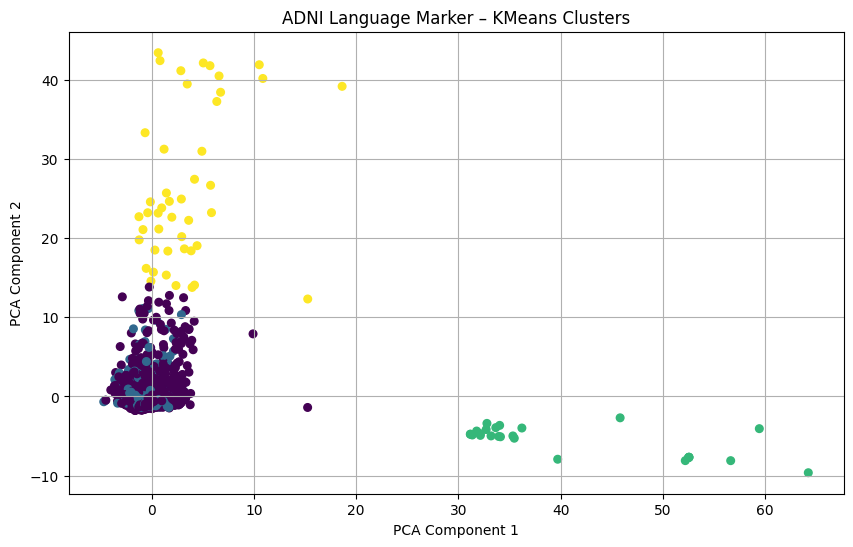

In [ ]:
# =============================================================
# 🧠 ADNI Language Marker Model (KMeans + SMOTE + SVM)
# =============================================================

# 📦 Imports
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, silhouette_score
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import pickle

# -------------------------------------------------------------
# 📥 Load ADNI Data
df = pd.read_csv("/content/language marker.csv")
print(f"✅ Loaded ADNI language dataset: {df.shape}")

# 🔢 Numeric features only
features = df.select_dtypes(include=[np.number]).fillna(0)

# ⚖️ Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# -------------------------------------------------------------
# 🎯 Pseudo-label generation using KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
pseudo_labels = kmeans.fit_predict(X_scaled)
df["Cluster"] = pseudo_labels

# 📊 Evaluate cluster quality
sil_score = silhouette_score(X_scaled, pseudo_labels)
print(f"\n🔍 Silhouette Score (ADNI Language): {round(sil_score, 4)}")

# -------------------------------------------------------------
# ⚖️ Balance clusters using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, df["Cluster"])

# -------------------------------------------------------------
# 🧠 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    stratify=y_resampled,
    random_state=42
)

# -------------------------------------------------------------
# 🚀 Train SVM with probability enabled
svm_model = SVC(kernel="rbf", probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# -------------------------------------------------------------
# 📈 Evaluate
y_pred = svm_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ SVM Accuracy (balanced): {round(acc * 100, 2)}%")
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
print("📉 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# -------------------------------------------------------------
# 💾 Save predictions for fusion
full_preds = svm_model.predict(X_scaled)
probs = svm_model.predict_proba(X_scaled)

pred_df = pd.DataFrame({
    "ID": df.index,
    "langmarker_pred": full_preds
})
pred_df.to_csv("adni_langmarker_svm_smote_preds.csv", index=False)
print("\n✅ Saved: adni_langmarker_svm_smote_preds.csv")

# -------------------------------------------------------------
# 💾 Save structured model results (for comparison)
adni_lang_results = {
    "model": svm_model,
    "y_pred": y_pred.tolist(),
    "p_pred": probs.tolist(),
    "cm": confusion_matrix(y_test, y_pred).tolist(),
    "silhouette_score": float(sil_score)
}

with open("adni_language_results.pkl", "wb") as f:
    pickle.dump(adni_lang_results, f)

print("💾 Saved: adni_language_results.pkl (for ADNI–CCNA cross-cohort comparison)")

# -------------------------------------------------------------
# 🎨 PCA visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
plt.figure(figsize=(10, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=pseudo_labels, cmap="viridis", s=30)
plt.title("ADNI Language Marker – KMeans Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()



🔍 Silhouette Score: 0.1294 (closer to 1 is better)

✅ SVM Accuracy (on pseudo-labels): 97.42%

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       514
           1       1.00      0.96      0.98       247
           2       1.00      0.80      0.89         5
           3       1.00      0.22      0.36         9

    accuracy                           0.97       775
   macro avg       0.99      0.74      0.80       775
weighted avg       0.97      0.97      0.97       775

📉 Confusion Matrix:
 [[513   1   0   0]
 [ 11 236   0   0]
 [  1   0   4   0]
 [  7   0   0   2]]

✅ Saved: langmarker_svm_preds.csv


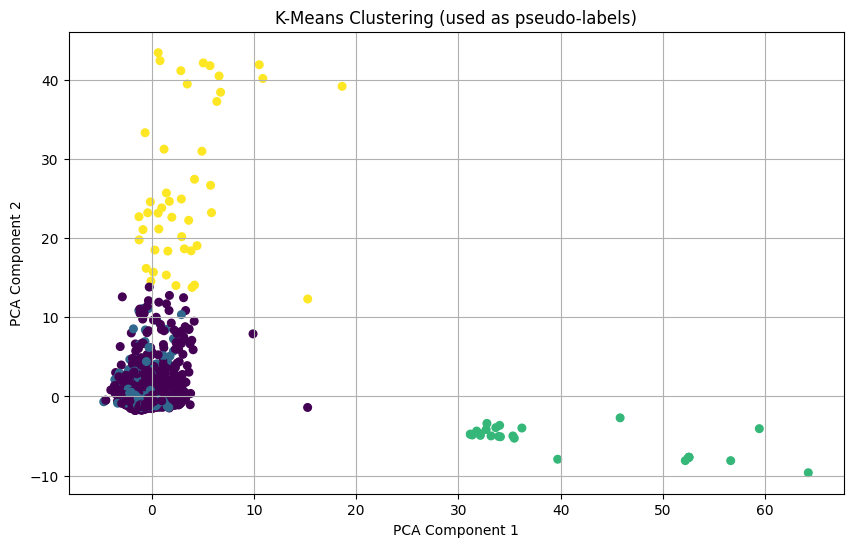

In [ ]:
# 📦 Step 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 📥 Step 2: Load Dataset
df = pd.read_csv("/content/language marker.csv")  # Update path if needed

# 🧹 Step 3: Use only numeric columns
features = df.select_dtypes(include=[np.number]).copy()
features = features.fillna(0)  # Handle NaNs if any

# ⚖️ Step 4: Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# 🎯 Step 5: Generate Pseudo-Labels using KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
pseudo_labels = kmeans.fit_predict(X_scaled)
df['Cluster'] = pseudo_labels  # Add to original data

# 📊 Step 6: Silhouette Score to check cluster quality
sil_score = silhouette_score(X_scaled, pseudo_labels)
print(f"\n🔍 Silhouette Score: {round(sil_score, 4)} (closer to 1 is better)")

# 🧠 Step 7: Train/Test Split for SVM
X = X_scaled
y = df['Cluster']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 🚀 Step 8: Train SVM
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)

# 📈 Step 9: Evaluate
y_pred = svm.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ SVM Accuracy (on pseudo-labels): {round(acc * 100, 2)}%")
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
print("📉 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# 💾 Step 10: Save for Fusion
pseudo_df = pd.DataFrame({
    'ID': df.index,  # Use actual ID column if available
    'langmarker_pred': df['Cluster']
})
pseudo_df.to_csv("langmarker_svm_preds.csv", index=False)
print("\n✅ Saved: langmarker_svm_preds.csv")

# 🎨 Step 11: Optional PCA Plot
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
plt.figure(figsize=(10, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=pseudo_labels, cmap='viridis', s=30)
plt.title("K-Means Clustering (used as pseudo-labels)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()
